Evaluating Porkchop orbital space...


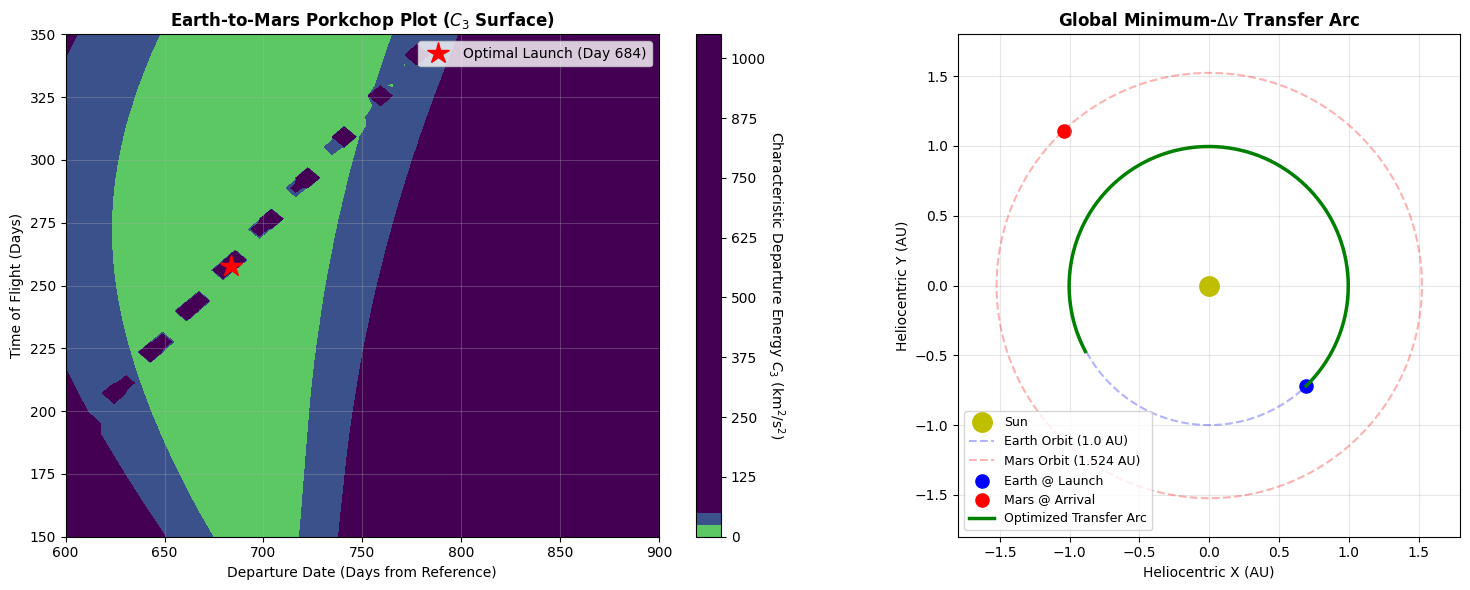

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar, differential_evolution

# -------------------------------------------------------------
# 1. Ephemeris & Orbital Mechanics Constants
# -------------------------------------------------------------
AU = 1.495978707e8         # km
MU_SUN = 1.32712440018e11  # km^3/s^2 (G * M_sun)
DAY = 86400.0              # seconds

r_earth = 1.0 * AU
r_mars = 1.524 * AU

v_e_orbit = np.sqrt(MU_SUN / r_earth)
v_m_orbit = np.sqrt(MU_SUN / r_mars)

omega_e = v_e_orbit / r_earth
omega_m = v_m_orbit / r_mars

def planet_state(r_orbit, omega, t_days):
    t_sec = t_days * DAY
    theta = omega * t_sec
    r_vec = np.array([r_orbit * np.cos(theta), r_orbit * np.sin(theta)])
    v_vec = np.array([-r_orbit * omega * np.sin(theta), r_orbit * omega * np.cos(theta)])
    return r_vec, v_vec

# -------------------------------------------------------------
# 2. Bulletproof Lambert Solver (Absolute Error Minimization)
# -------------------------------------------------------------
def solve_lambert(r1_vec, r2_vec, tof_days):
    r1 = np.linalg.norm(r1_vec)
    r2 = np.linalg.norm(r2_vec)
    tof_sec = tof_days * DAY

    cos_dnu = np.clip(np.dot(r1_vec, r2_vec) / (r1 * r2), -0.9999, 0.9999)
    dnu = np.arccos(cos_dnu)

    if (r1_vec[0]*r2_vec[1] - r1_vec[1]*r2_vec[0]) < 0:
        dnu = 2.0 * np.pi - dnu

    A = np.sin(dnu) * np.sqrt(r1 * r2 / (1.0 - cos_dnu))

    def tof_error(z):
        if z > 1e-4:
            sqz = np.sqrt(z)
            c = (1.0 - np.cos(sqz)) / z
            s = (sqz - np.sin(sqz)) / (sqz**3)
        elif z < -1e-4:
            sqz = np.sqrt(-z)
            c = (np.cosh(sqz) - 1.0) / (-z)
            s = (np.sinh(sqz) - sqz) / (sqz**3)
        else:
            c = 0.5
            s = 1.0 / 6.0

        y = r1 + r2 + A * (z * s - 1.0) / np.sqrt(c)
        if y <= 0: return 1e12

        t_calc = ((y / c)**1.5 * s + A * np.sqrt(y)) / np.sqrt(MU_SUN)
        return abs(t_calc - tof_sec)

    res = minimize_scalar(tof_error, bounds=(-4*np.pi**2, 4*np.pi**2), method='bounded')
    if not res.success or res.fun > 100:
        return None, None

    z = res.x
    if z > 1e-4:
        c = (1.0 - np.cos(np.sqrt(z))) / z
        s = (np.sqrt(z) - np.sin(np.sqrt(z))) / (z**1.5)
    elif z < -1e-4:
        c = (np.cosh(np.sqrt(-z)) - 1.0) / (-z)
        s = (np.sinh(np.sqrt(-z)) - np.sqrt(-z)) / ((-z)**1.5)
    else:
        c = 0.5; s = 1.0 / 6.0

    y = r1 + r2 + A * (z * s - 1.0) / np.sqrt(c)
    f = 1.0 - y / r1
    g = A * np.sqrt(y / MU_SUN)
    g_dot = 1.0 - y / r2

    v1 = (r2_vec - f * r1_vec) / g
    v2 = (g_dot * r2_vec - r1_vec) / g
    return v1, v2

# -------------------------------------------------------------
# 3. Porkchop Grid Evaluation (Shifted to Natural Launch Window)
# -------------------------------------------------------------
print("Evaluating Porkchop orbital space...")
launch_days = np.linspace(600, 900, 50)
tof_days = np.linspace(150, 350, 50)
C3 = np.full((len(tof_days), len(launch_days)), np.nan)

for j, t_l in enumerate(launch_days):
    r1, v1_p = planet_state(r_earth, omega_e, t_l)
    for i, tof in enumerate(tof_days):
        r2, v2_p = planet_state(r_mars, omega_m, t_l + tof)
        v1, v2 = solve_lambert(r1, r2, tof)
        if v1 is not None:
            C3[i, j] = np.linalg.norm(v1 - v1_p)**2

# -------------------------------------------------------------
# 4. Global Minimum-Delta-V Optimization
# -------------------------------------------------------------
def total_cost(params):
    t_l, tof = params
    r1, v1_p = planet_state(r_earth, omega_e, t_l)
    r2, v2_p = planet_state(r_mars, omega_m, t_l + tof)
    v1, v2 = solve_lambert(r1, r2, tof)

    if v1 is None: return 1e6
    return np.linalg.norm(v1 - v1_p) + np.linalg.norm(v2 - v2_p)

res = differential_evolution(total_cost, [(650, 850), (150, 350)], seed=42)
best_t_launch, best_tof = res.x

r1_opt, v1_p_opt = planet_state(r_earth, omega_e, best_t_launch)
r2_opt, v2_p_opt = planet_state(r_mars, omega_m, best_t_launch + best_tof)
v1_opt, v2_opt = solve_lambert(r1_opt, r2_opt, best_tof)

opt_c3 = np.linalg.norm(v1_opt - v1_p_opt)**2
opt_v_arr = np.linalg.norm(v2_opt - v2_p_opt)

# -------------------------------------------------------------
# 5. Dual Visualization Output
# -------------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Auto-scaling contours to guarantee visibility
X, Y = np.meshgrid(launch_days, tof_days)
cp = ax1.contourf(X, Y, C3, levels=40, cmap='viridis_r', vmax=50)
cbar = plt.colorbar(cp, ax=ax1)
cbar.set_label('Characteristic Departure Energy $C_3$ (km$^2$/s$^2$)', rotation=270, labelpad=15)

ax1.plot(best_t_launch, best_tof, 'r*', markersize=16, label=f"Optimal Launch (Day {best_t_launch:.0f})")
ax1.set_title("Earth-to-Mars Porkchop Plot ($C_3$ Surface)", fontweight='bold')
ax1.set_xlabel("Departure Date (Days from Reference)")
ax1.set_ylabel("Time of Flight (Days)")
ax1.legend(loc="upper right")
ax1.grid(True, alpha=0.3)

steps = 400
dt = (best_tof * DAY) / steps
traj = np.zeros((steps, 2))
r_curr = r1_opt.copy()
v_curr = v1_opt.copy()

for s in range(steps):
    traj[s] = r_curr / AU
    r_mag = np.linalg.norm(r_curr)
    v_curr += - (MU_SUN / (r_mag**3)) * r_curr * dt
    r_curr += v_curr * dt

theta = np.linspace(0, 2*np.pi, 300)
ax2.plot(0, 0, 'yo', markersize=14, label="Sun")
ax2.plot(np.cos(theta), np.sin(theta), 'b--', alpha=0.3, label="Earth Orbit (1.0 AU)")
ax2.plot(1.524*np.cos(theta), 1.524*np.sin(theta), 'r--', alpha=0.3, label="Mars Orbit (1.524 AU)")

ax2.scatter(r1_opt[0]/AU, r1_opt[1]/AU, color='blue', s=90, label="Earth @ Launch")
ax2.scatter(r2_opt[0]/AU, r2_opt[1]/AU, color='red', s=90, label="Mars @ Arrival")
ax2.plot(traj[:, 0], traj[:, 1], 'g-', linewidth=2.5, label="Optimized Transfer Arc")

ax2.set_title("Global Minimum-$\\Delta v$ Transfer Arc", fontweight='bold')
ax2.set_xlabel("Heliocentric X (AU)")
ax2.set_ylabel("Heliocentric Y (AU)")
ax2.set_xlim(-1.8, 1.8)
ax2.set_ylim(-1.8, 1.8)
ax2.set_aspect('equal')
ax2.legend(loc="lower left", fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()